<h1 id="#-Figure-1-UMAPs,-plots"># Figure Plots</h1>

In [2]:
import scanpy as sc
import anndata
from scipy import io
import scipy
from scipy.sparse import coo_matrix, csr_matrix
import numpy as np
import os
import pickle
import pandas as pd
import matplotlib.pyplot as pl
import matplotlib.pyplot as plt
from matplotlib import rcParams
import seaborn as sns
import matplotlib as mpl
import matplotlib as mp
mpl.rcParams['pdf.fonttype'] = 42

sc.settings.set_figure_params(facecolor='white', dpi=100, frameon=False)

import matplotlib.colors

<h1 id="read-in-original-object">read in final object</h1>

In [3]:
adata = sc.read_h5ad('/share/crsp/lab/dalawson/tzhuravl/PROJECT_DATA_INFO_LINKS_etc/objects_for_zenodo/merged_no_mets_no_lymph_node_processed.h5ad')

In [69]:
sub = adata[~adata.obs['mouse_id'].isin(['mutant_5_five_pooled','mutant_4_four_pooled',
                                'wildtype_5_five_pooled','wildtype_4_two_pooled'])]

In [75]:
sub.obs['sc_TNBC_subtype'].value_counts()

sc_TNBC_subtype
M      26846
BL2     4372
BL1     2272
LAR      934
UNS        3
Name: count, dtype: int64

In [31]:
sub = sub[~sub.obs['sc_TNBC_subtype'].isin(['UNS'])]

In [77]:
sub

View of AnnData object with n_obs × n_vars = 56561 × 1435
    obs: 'nCount_RNA', 'nFeature_RNA', 'orig_ident', 'pct_counts_mt', 'pct_counts_ribo', 'singlet_or_doublet', 'barcode', 'genotype', 'condition', 'cellplex_batch_id', 'mouse_id', 'internal_cell_state', 'UMAP_1', 'UMAP_2', 'n_genes_by_counts', 'log1p_n_genes_by_counts', 'total_counts', 'log1p_total_counts', 'pct_counts_in_top_50_genes', 'pct_counts_in_top_100_genes', 'pct_counts_in_top_200_genes', 'pct_counts_in_top_500_genes', 'total_counts_mt', 'log1p_total_counts_mt', 'total_counts_ribo', 'log1p_total_counts_ribo', 'leiden', 'cell_type', 'sample_id', 'age_months', 'facs_enrichment_type', 'ploidy', 'sc_genotype', 'S_score', 'G2M_score', 'cell_cycle_phase', 'sc_TNBC_subtype_correlation', 'sc_TNBC_subtype_p_value', 'sc_TNBC_subtype', 'human_adult_atlas_cell_state', 'mouse_development_atlas_cell_state', 'scaled_combined_lumsec_basal'
    var: 'n_cells', 'mc_Fano', 'FDR_adj_pvalue', 'p_value', 'highly_variable', 'mt', 'ribo', 'n_c

/opt/apps/python/3.10.2/lib/python3.10/site-packages/scanpy/plotting/_utils.py:465: ImplicitModificationWarning: Trying to modify attribute `._uns` of view, initializing view as actual.
  adata.uns[value_to_plot + "_colors"] = colors_list


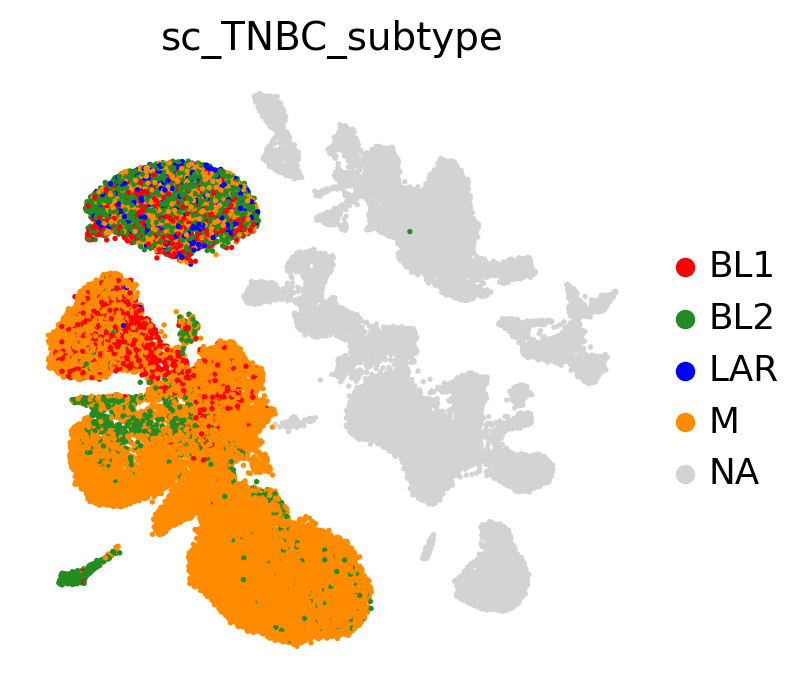

In [79]:
sc.pl.umap(sub, color='sc_TNBC_subtype',size=15,palette=['red',
                                                'forestgreen',
                                                'blue',
                                               'darkorange',
                                               'grey'])

In [80]:
sub = sub[sub.obs['cell_type'].isin(['Bmyo','LumSec','LumHS','tumor'])]

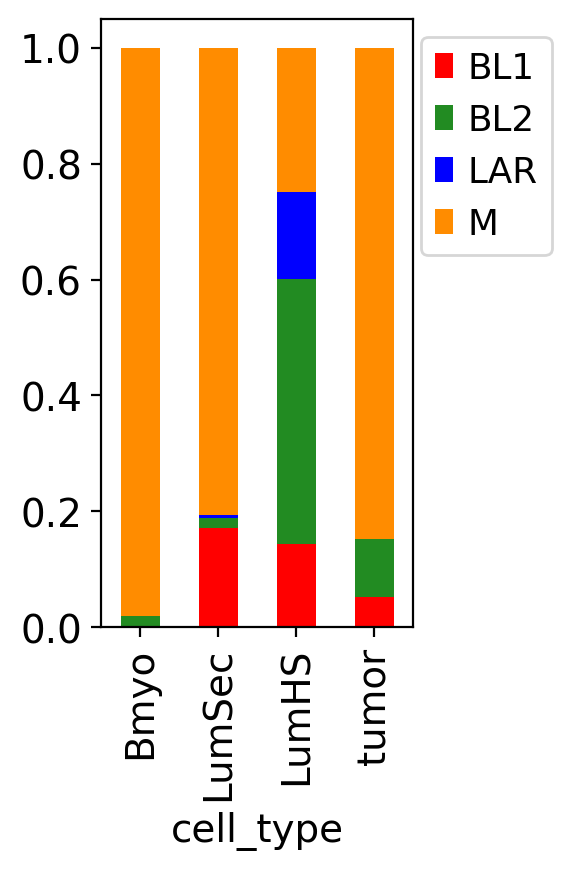

In [95]:
tmp = pd.crosstab(sub.obs['sc_TNBC_subtype'],sub.obs['cell_type'], 
                  normalize='columns')[['Bmyo','LumSec','LumHS','tumor']].T.plot(kind='bar',figsize=(2, 4),
                                                                                                            stacked=True, color=['red',
                                                'forestgreen',
                                                'blue',
                                               'darkorange',
                                               'grey'])
tmp.legend(title='', bbox_to_anchor=(1.5, 1),loc='upper right')
plt.grid(None)
pl.savefig('cell_type_vs_subtype_stackedbar_plot.pdf', bbox_inches='tight')

In [28]:
tum = sub[sub.obs['ploidy'].isin(['aneuploid'])]
tum = tum[tum.obs['condition'].isin(['tumor'])]
tum = tum[~tum.obs['sc_TNBC_subtype'].isin(['LAR'])]

In [29]:
tum.obs['sc_TNBC_subtype'].value_counts()

sc_TNBC_subtype
M      10052
BL2     1187
BL1      761
UNS        2
Name: count, dtype: int64

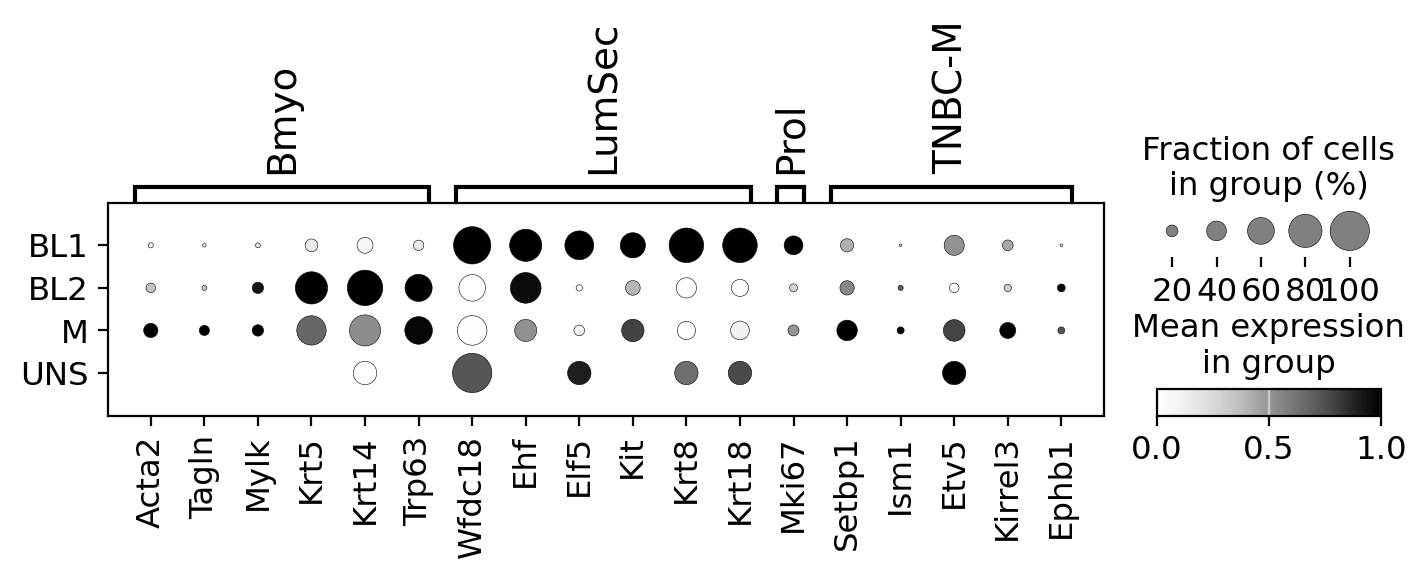

In [32]:
marker_genes = {
    "Bmyo": ["Acta2","Tagln","Mylk","Krt5","Krt14","Trp63"],
    "LumSec": ["Wfdc18","Ehf","Elf5","Kit","Krt8","Krt18"],
    "Prol": ["Mki67"],
    "TNBC-M":["Setbp1","Ism1","Etv5","Kirrel3","Ephb1"]}


sc.pl.dotplot(tum, marker_genes, groupby="sc_TNBC_subtype",
              standard_scale="var",swap_axes=False,cmap="Grays",
              save='_Fig2_sc_TNBC_subtype.pdf'
             )

In [33]:
sub = adata[adata.obs['cell_type'].isin(['Bmyo','LumSec','tumor'])]
sub = sub[~sub.obs['condition'].isin(['mutant'])]

In [34]:
sub = sub[~((sub.obs['condition'] == 'wildtype') & (sub.obs['cell_type'] == 'tumor'))]

In [35]:
substring = 'tumor'

sub.obs['celltype_or_tumor_id'] = np.where(~sub.obs['condition'].str.contains(substring, na=False),  # Condition (inverted: ~ means NOT)
                   sub.obs['cell_type'],                                    # Value if condition is True (use 'a')
                   sub.obs['sample_id'])

sub.obs['celltype_or_tumor_id'].value_counts()

/tmp/ipykernel_1432564/2309449227.py:3: ImplicitModificationWarning: Trying to modify attribute `.obs` of view, initializing view as actual.
  sub.obs['celltype_or_tumor_id'] = np.where(~sub.obs['condition'].str.contains(substring, na=False),  # Condition (inverted: ~ means NOT)


celltype_or_tumor_id
Bmyo            7812
tumor_4_8mm     4356
tumor_5_25mm    2365
tumor_3_2mm     2250
LumSec          2088
tumor_6_25mm    1782
tumor_2_1mm      594
tumor_1_1mm      554
tumor_7_25mm     517
Name: count, dtype: int64

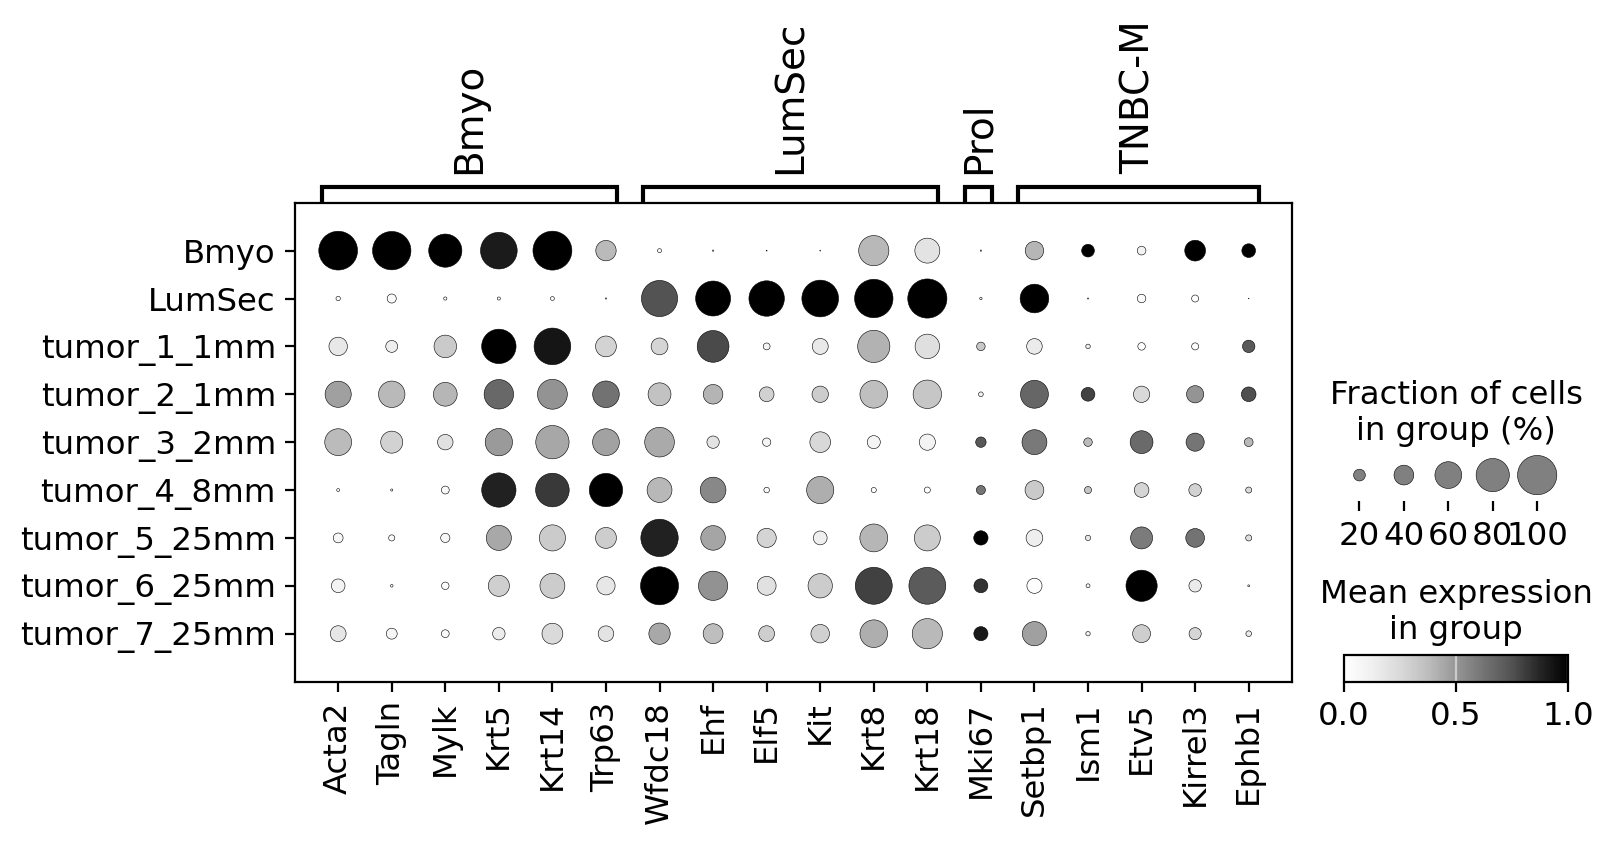

In [36]:
sc.pl.dotplot(sub, marker_genes, groupby="celltype_or_tumor_id",
              standard_scale="var",swap_axes=False,cmap="Grays",
              save='_Fig2_each_tumor.pdf'
             )

# epithelial subset embedding

In [37]:
work_dir = '/share/crsp/lab/dalawson/tzhuravl/CellPlex_Tumors/Scanpy_Seurat/scVI_epithelial'

epi = pickle.load(open(os.path.join(work_dir, 'epithelial_no_LN_no_LumHR_no_schwann_bigsur_scvi.pkl'), 'rb'))

In [38]:
sub=adata[adata.obs['cell_type'].isin(['Bmyo','LumSec','tumor'])]

In [39]:
epi.obs=sub.obs.copy()

In [40]:
epi

AnnData object with n_obs × n_vars = 33293 × 1333
    obs: 'nCount_RNA', 'nFeature_RNA', 'orig_ident', 'pct_counts_mt', 'pct_counts_ribo', 'singlet_or_doublet', 'barcode', 'genotype', 'condition', 'cellplex_batch_id', 'mouse_id', 'internal_cell_state', 'UMAP_1', 'UMAP_2', 'n_genes_by_counts', 'log1p_n_genes_by_counts', 'total_counts', 'log1p_total_counts', 'pct_counts_in_top_50_genes', 'pct_counts_in_top_100_genes', 'pct_counts_in_top_200_genes', 'pct_counts_in_top_500_genes', 'total_counts_mt', 'log1p_total_counts_mt', 'total_counts_ribo', 'log1p_total_counts_ribo', 'leiden', 'cell_type', 'sample_id', 'age_months', 'facs_enrichment_type', 'ploidy', 'sc_genotype', 'S_score', 'G2M_score', 'cell_cycle_phase', 'sc_TNBC_subtype_correlation', 'sc_TNBC_subtype_p_value', 'sc_TNBC_subtype', 'human_adult_atlas_cell_state', 'mouse_development_atlas_cell_state', 'scaled_combined_lumsec_basal'
    var: 'n_cells', 'mc_Fano', 'FDR_adj_pvalue', 'p_value', 'highly_variable', 'mt', 'ribo', 'n_cells_by_

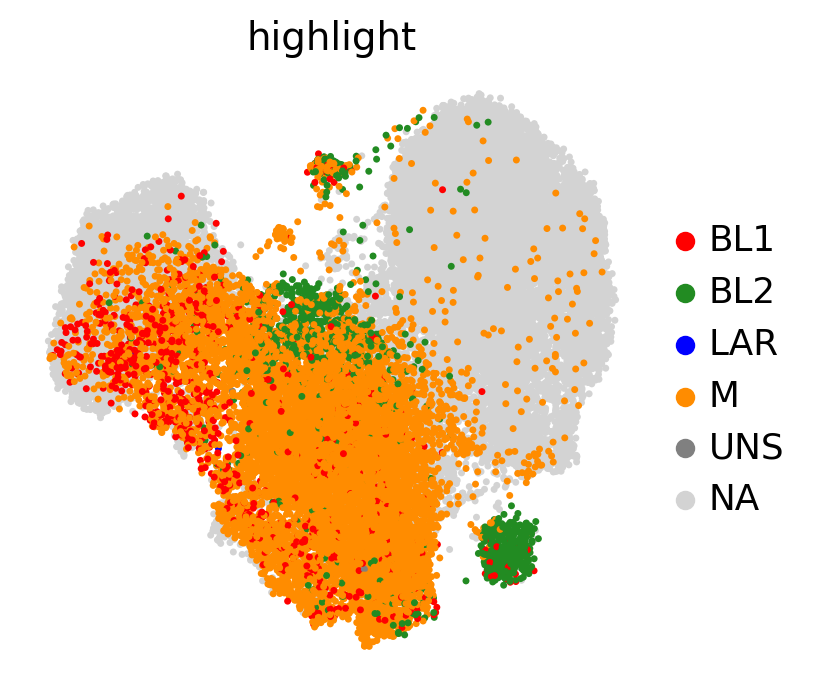

In [41]:
tum = epi[epi.obs['ploidy'].isin(['aneuploid'])]
tum = tum[tum.obs['condition'].isin(['tumor'])]

epi.obs['highlight']=tum.obs['sc_TNBC_subtype']
sc.pl.umap(epi, color='highlight',size=25,palette=['red',
                                                'forestgreen',
                                                'blue',
                                               'darkorange',
                                               'grey'])

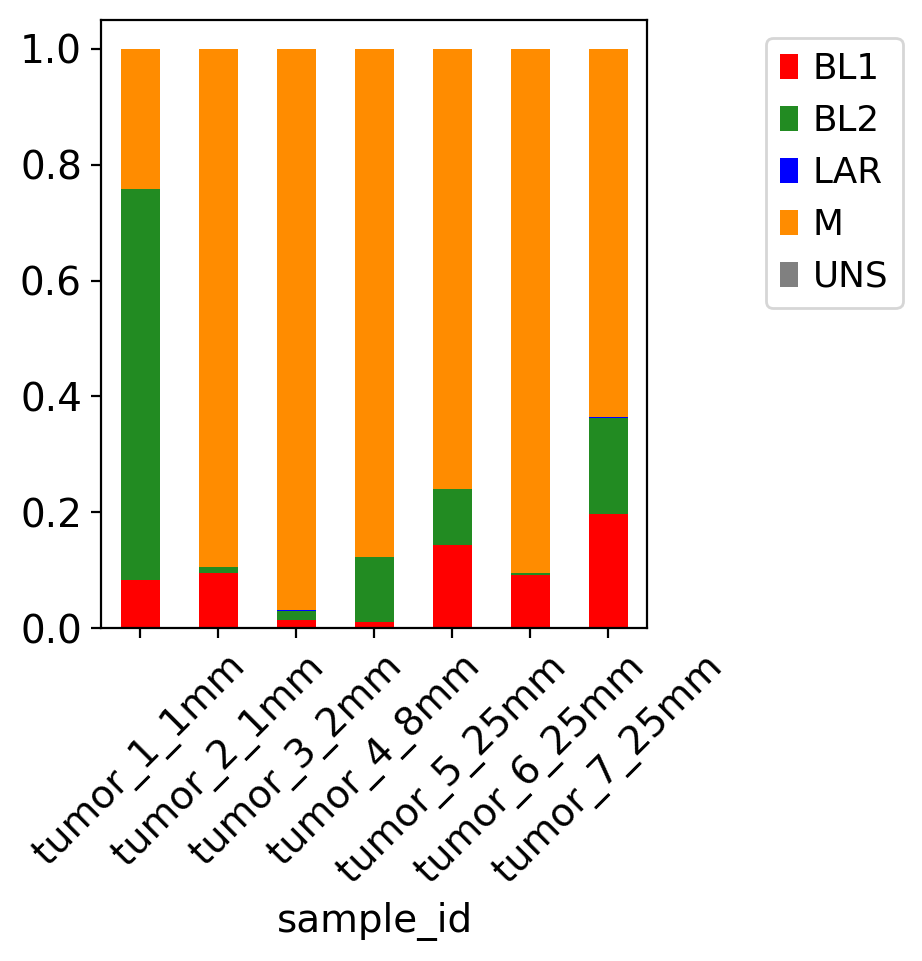

In [46]:
tmp = pd.crosstab(epi.obs['highlight'],epi.obs['sample_id'], 
                  normalize='columns')[["tumor_1_1mm","tumor_2_1mm","tumor_3_2mm","tumor_4_8mm","tumor_5_25mm","tumor_6_25mm","tumor_7_25mm"]].T.plot(kind='bar',figsize=(3.5, 4),
                                                                                                            stacked=True, color=['red',
                                                'forestgreen',
                                                'blue',
                                               'darkorange',
                                               'grey'])
tmp.legend(title='', bbox_to_anchor=(1.5, 1),loc='upper right')
pl.xticks(rotation=45)
plt.grid(None)
pl.savefig('aneuploid_tumor_vs_subtype_stackedbar_plot.pdf', bbox_inches='tight')

<h1 id="Walid-Khaled-Bach-et-al">Walid Khaled Bach et al - all cells</h1>

In [47]:
adata = sc.read_h5ad('/share/crsp/lab/dalawson/share/Brca_mouse/WalidKhaled/all_cells_bigsur_merged.h5ad')

In [52]:
sub = adata[~adata.obs['sc_TNBC_subtype'].isin(['UNS'])]

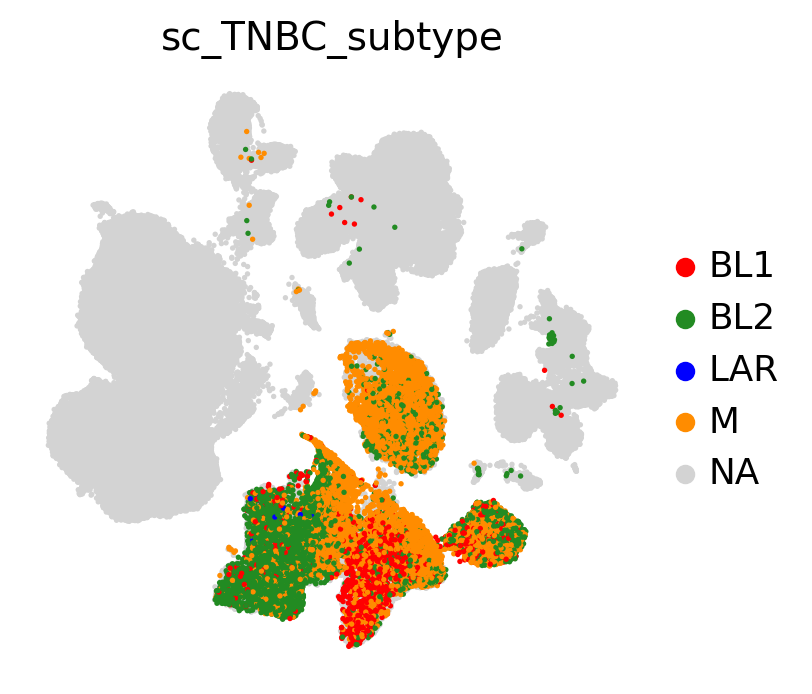

In [54]:
sc.pl.umap(sub, color='sc_TNBC_subtype',s=15)

In [56]:
sub.obs['sc_TNBC_subtype'].value_counts()

sc_TNBC_subtype
M      8003
BL2    7067
BL1    1755
LAR      30
Name: count, dtype: int64

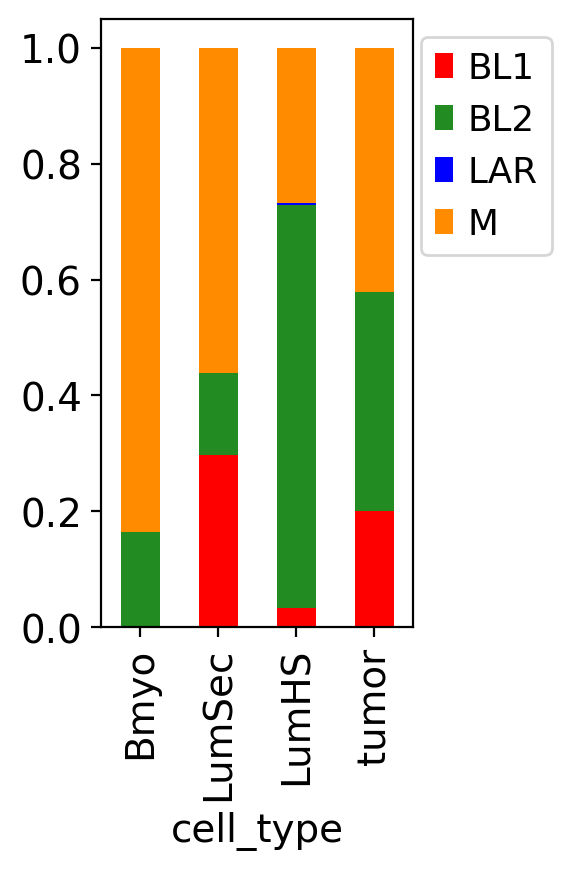

In [58]:
tmp = pd.crosstab(sub.obs['sc_TNBC_subtype'],sub.obs['cell_type'], 
                  normalize='columns')[['Bmyo','LumSec','LumHS','tumor']].T.plot(kind='bar',figsize=(2, 4),
                                                                                                            stacked=True, color=['red',
                                                'forestgreen',
                                                'blue',
                                               'darkorange',
                                               'grey'])
tmp.legend(title='', bbox_to_anchor=(1.5, 1),loc='upper right')
plt.grid(None)
pl.savefig('cell_type_vs_subtype_stackedbar_plot.pdf', bbox_inches='tight')

<h1>Walid Khaled Bach et al - epithelial subset</h1>

In [59]:
sub = adata[adata.obs['cell_type'].isin(['Bmyo',
                                           'LumSec',
                                           'tumor'])]

In [60]:
work_dir = '/share/crsp/lab/dalawson/share/Brca_mouse/WalidKhaled'

epi = pickle.load(open(os.path.join(work_dir, 'epithelial_epi_no_LumHR_bigsur_scvi_from_all.pkl'), 'rb'))

In [61]:
epi.obs=sub.obs.copy()

In [63]:
epi = epi[~epi.obs['sc_TNBC_subtype'].isin(['UNS'])]

In [64]:
sub.obs['Group'].value_counts()

Group
WKBR_MG       17729
Control        5130
WKBR_Tumor     3121
Name: count, dtype: int64

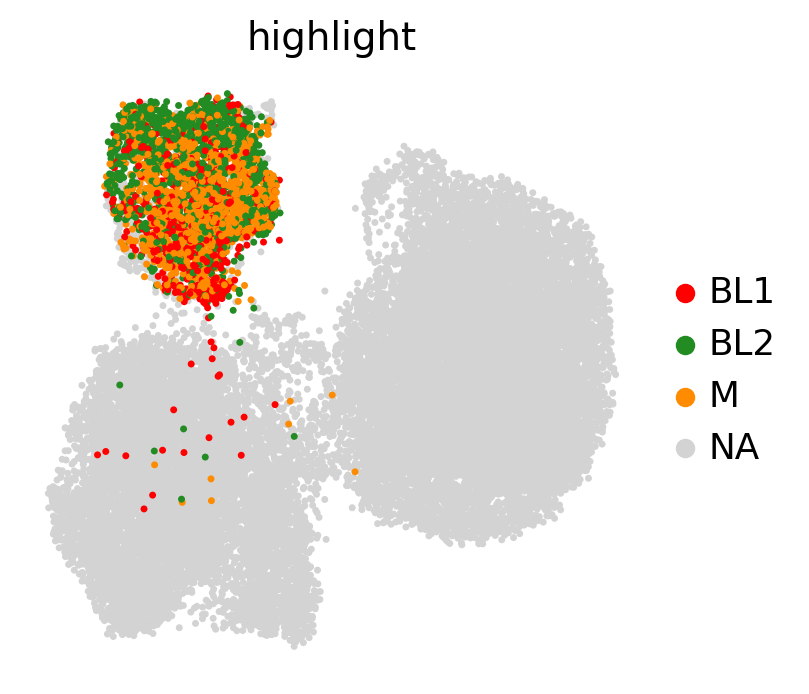

In [66]:
tum = epi[epi.obs['ploidy'].isin(['aneuploid'])]
tum = tum[tum.obs['Group'].isin(['WKBR_Tumor'])]

epi.obs['highlight']=tum.obs['sc_TNBC_subtype']
sc.pl.umap(epi, color='highlight',size=25,palette=['red',
                                                'forestgreen',
                                               'darkorange',
                                               'grey'])

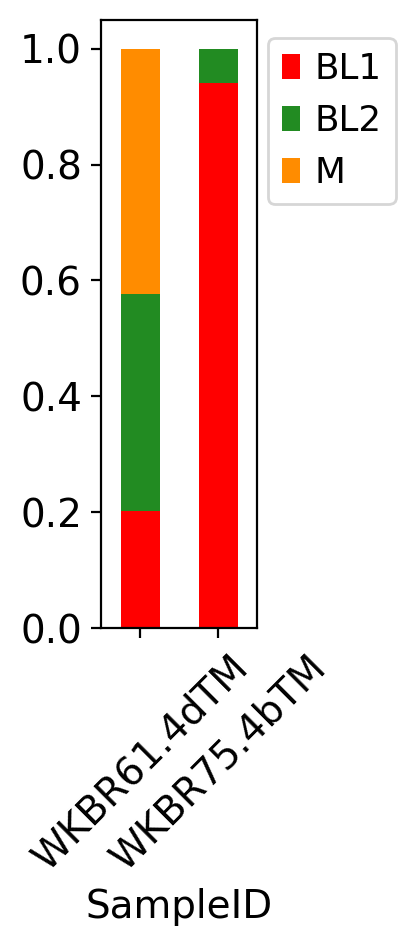

In [71]:
tmp = pd.crosstab(epi.obs['highlight'],epi.obs['SampleID'], 
                  normalize='columns').T.plot(kind='bar',figsize=(1, 4),
                                                                                                            stacked=True, color=['red',
                                                'forestgreen',
                                               'darkorange',
                                               'grey'])
tmp.legend(title='', bbox_to_anchor=(2, 1),loc='upper right')
pl.xticks(rotation=45)
plt.grid(None)
pl.savefig('aneuploid_tumor_vs_subtype_stackedbar_plot.pdf', bbox_inches='tight')

In [ ]:
# merged dotplot

In [8]:
adata = sc.read_h5ad('/share/crsp/lab/dalawson/tzhuravl/PROJECT_DATA_INFO_LINKS_etc/objects_for_zenodo/merged_no_mets_no_lymph_node_processed.h5ad')

In [9]:
adata = adata[adata.obs['cell_type'].isin(['Bmyo',
                                           'LumSec',
                                           'tumor'])]

adata = adata[~adata.obs['condition'].isin(['mutant'])]
adata = adata[~((adata.obs['condition'] == 'wildtype') & (adata.obs['cell_type'] == 'tumor'))]
adata = adata[~((adata.obs['condition'] == 'tumor') & (adata.obs['ploidy'] == 'diploid'))]
adata = adata[~((adata.obs['condition'] == 'tumor') & (adata.obs['ploidy'] == 'not.defined'))]

adata = adata[~adata.obs['mouse_id'].isin(['mutant_5_five_pooled','mutant_4_four_pooled',
                                'wildtype_5_five_pooled','wildtype_4_two_pooled'])]

In [13]:
adata.obs['cell_type_dataset'] = (
    adata.obs["cell_type"]
    .map(lambda x: {"tumor": "tumor_wap"}.get(x, x))
    .astype("category")
)

/tmp/ipykernel_616272/1984106315.py:1: ImplicitModificationWarning: Trying to modify attribute `.obs` of view, initializing view as actual.
  adata.obs['cell_type_dataset'] = (


In [16]:
sub=adata

In [23]:
adata = sc.read_h5ad('/share/crsp/lab/dalawson/share/Brca_mouse/WalidKhaled/all_cells_bigsur_merged.h5ad')

In [24]:
adata = adata[adata.obs['cell_type'].isin(['Bmyo',
                                           'LumSec',
                                           'tumor'])]

adata = adata[~adata.obs['Group'].isin(['WKBR_MG'])]
adata = adata[~((adata.obs['Group'] == 'Control') & (adata.obs['cell_type'] == 'tumor'))]
adata = adata[~((adata.obs['Group'] == 'tumor') & (adata.obs['ploidy'] == 'diploid'))]
adata = adata[~((adata.obs['Group'] == 'tumor') & (adata.obs['ploidy'] == 'not.defined'))]

adata = adata[~adata.obs['SampleID'].isin(['CBLT','CBLA13'])]

In [27]:
adata.obs['cell_type_dataset'] = (
    adata.obs["cell_type"]
    .map(lambda x: {"tumor": "tumor_blg"}.get(x, x))
    .astype("category")
)

/tmp/ipykernel_616272/2498076988.py:1: ImplicitModificationWarning: Trying to modify attribute `.obs` of view, initializing view as actual.
  adata.obs['cell_type_dataset'] = (


In [28]:
adata.obs['cell_type_dataset'].value_counts()

cell_type_dataset
tumor_blg    3052
LumSec        880
Bmyo          819
Name: count, dtype: int64

In [29]:
sub.obs['batch'] = 'wap'
adata.obs['batch'] = 'blg'

In [31]:
combined_adata = anndata.concat([sub, adata], join="outer", label="batch_key")

In [32]:
combined_adata

AnnData object with n_obs × n_vars = 24614 × 1781
    obs: 'nCount_RNA', 'nFeature_RNA', 'orig_ident', 'pct_counts_mt', 'pct_counts_ribo', 'singlet_or_doublet', 'barcode', 'genotype', 'condition', 'cellplex_batch_id', 'mouse_id', 'internal_cell_state', 'UMAP_1', 'UMAP_2', 'n_genes_by_counts', 'log1p_n_genes_by_counts', 'total_counts', 'log1p_total_counts', 'pct_counts_in_top_50_genes', 'pct_counts_in_top_100_genes', 'pct_counts_in_top_200_genes', 'pct_counts_in_top_500_genes', 'total_counts_mt', 'log1p_total_counts_mt', 'total_counts_ribo', 'log1p_total_counts_ribo', 'leiden', 'cell_type', 'sample_id', 'age_months', 'facs_enrichment_type', 'ploidy', 'sc_genotype', 'S_score', 'G2M_score', 'cell_cycle_phase', 'sc_TNBC_subtype_correlation', 'sc_TNBC_subtype_p_value', 'sc_TNBC_subtype', 'human_adult_atlas_cell_state', 'mouse_development_atlas_cell_state', 'scaled_combined_lumsec_basal', 'cell_type_dataset', 'batch', 'orig.ident', 'nCount_originalexp', 'nFeature_originalexp', 'Sample', 'Seq

In [33]:
combined_adata.obs['cell_type_dataset'].value_counts()

cell_type_dataset
tumor_wap    11583
Bmyo          6950
tumor_blg     3052
LumSec        3029
Name: count, dtype: int64

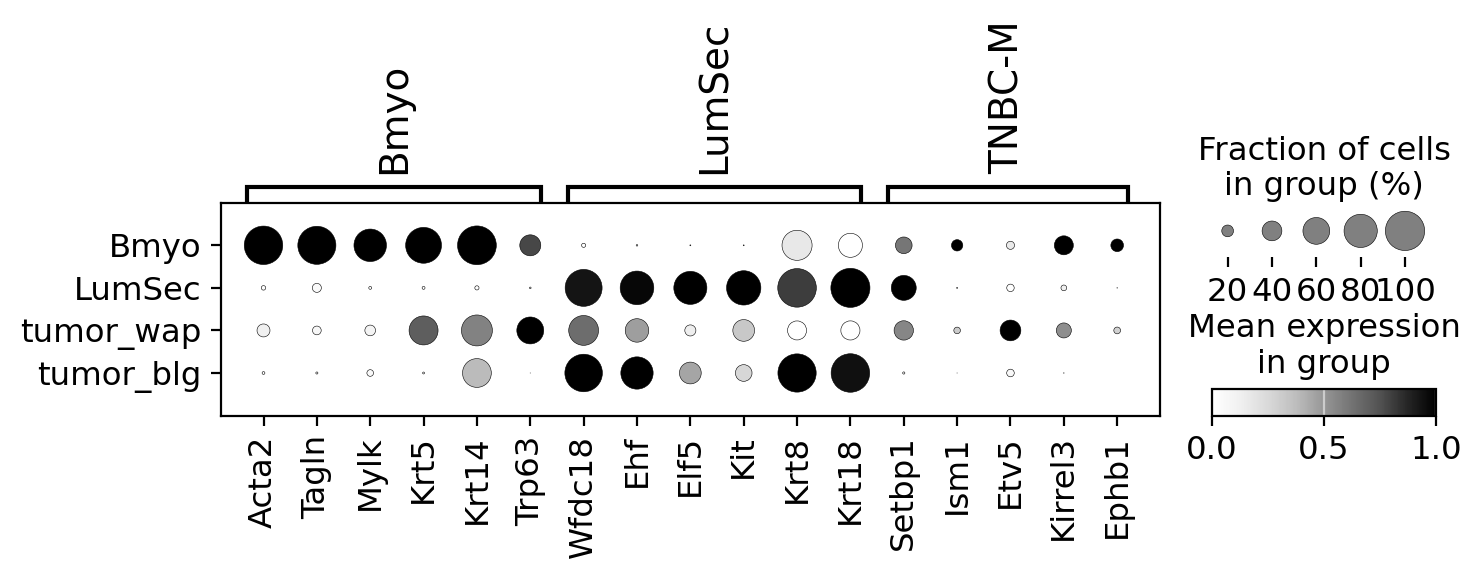

In [38]:
marker_genes = {
    "Bmyo": ["Acta2","Tagln","Mylk","Krt5","Krt14","Trp63"],
    "LumSec": ["Wfdc18","Ehf","Elf5","Kit","Krt8","Krt18"],
    "TNBC-M":["Setbp1","Ism1","Etv5","Kirrel3","Ephb1"]}


sc.pl.dotplot(combined_adata, marker_genes, groupby="cell_type_dataset",standard_scale="var",
              categories_order=['Bmyo','LumSec','tumor_wap','tumor_blg'],
              swap_axes=False,cmap='Greys',save='_fig_2_canonical_tnbcM.pdf')

In [60]:
data = {
    'Category': ['BL1', 'BL2', 'LAR', 'M', 'UNC'],
    'BRCA1': [9,13,2,10,1],
    'WT': [5,0,5,4,2],
    'TCGA': [40,32,14,44,2]
}
df = pd.DataFrame(data)
df = df.set_index('Category')

df_normalized = df.div(df.sum(axis=0), axis=1) * 100
print(df_normalized)

              BRCA1     WT       TCGA
Category                             
BL1       25.714286  31.25  30.303030
BL2       37.142857   0.00  24.242424
LAR        5.714286  31.25  10.606061
M         28.571429  25.00  33.333333
UNC        2.857143  12.50   1.515152


In [61]:
data = {
    'Category': ['UNC','M','LAR','BL2','BL1'],
    'BRCA1': [1,10,2,13,9],
    'WT': [2,4,5,0,5],
    'TCGA': [2,44,14,32,40]
}
df = pd.DataFrame(data)
df = df.set_index('Category')

df_normalized = df.div(df.sum(axis=0), axis=1) * 100
print(df_normalized)

              BRCA1     WT       TCGA
Category                             
UNC        2.857143  12.50   1.515152
M         28.571429  25.00  33.333333
LAR        5.714286  31.25  10.606061
BL2       37.142857   0.00  24.242424
BL1       25.714286  31.25  30.303030


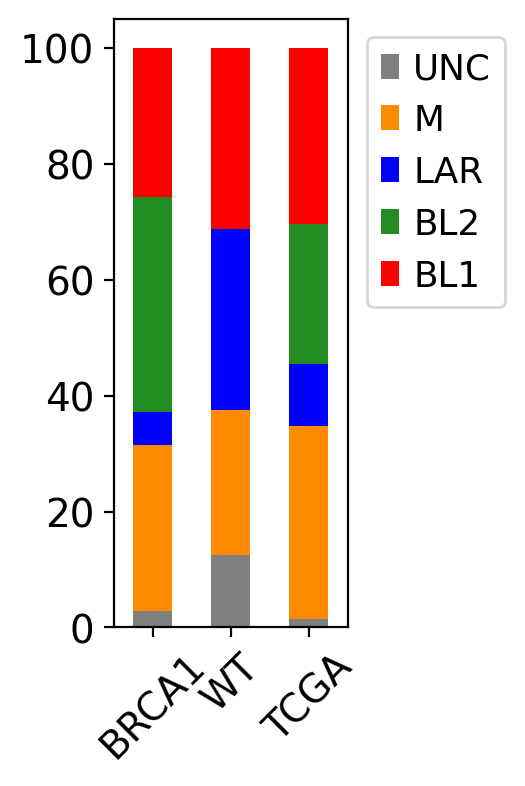

In [64]:
ax = df_normalized.T.plot(kind='bar',figsize=(1.5, 4),
                          stacked=True, color=['grey','darkorange','blue','forestgreen','red'])
ax.legend(title='', bbox_to_anchor=(1.75, 1),loc='upper right')
pl.xticks(rotation=45)
plt.grid(None)
pl.savefig('bulk_subtypes_stackedbar_plot.pdf', bbox_inches='tight')

In [ ]:
data = {
    'Category': ['UNC','M','LAR','BL2','BL1'],
    'WAP_Cre': [0,5,0,1,1],
    'BLG_Cre': [0,0,0,0,2]
}
df = pd.DataFrame(data)
df = df.set_index('Category')

df_normalized = df.div(df.sum(axis=0), axis=1) * 100
print(df_normalized)

            WAP_Cre  BLG_Cre
Category                    
UNC        0.000000      0.0
M         71.428571      0.0
LAR        0.000000      0.0
BL2       14.285714      0.0
BL1       14.285714    100.0


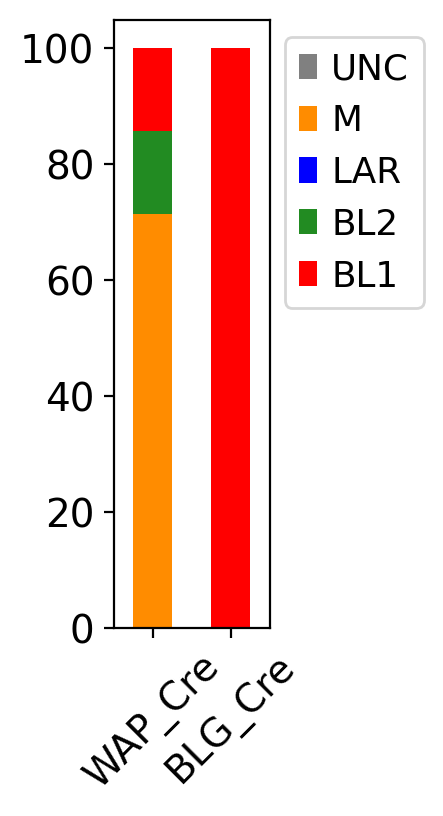

In [ ]:
ax = df_normalized.T.plot(kind='bar',figsize=(1, 4),
                          stacked=True, color=['grey','darkorange','blue','forestgreen','red'])
ax.legend(title='', bbox_to_anchor=(2.1, 1),loc='upper right')
pl.xticks(rotation=45)
plt.grid(None)
pl.savefig('psuedobulk_subtypes_stackedbar_plot.pdf', bbox_inches='tight')